In [1]:
%reload_ext autoreload

%autoreload 2

%reload_ext dotenv
%dotenv

In [2]:
import cf_xarray
import datetime
import functools
import IPython
from IPython.display import HTML, display_html
import math
import matplotlib
from matplotlib import animation
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import string
import xarray as xr

from mlde_utils import cp_model_rotated_pole, VariableMetadata
from mlde_analysis import DERIVED_DATA, plot_map
from mlde_analysis.display import pretty_table, VAR_RANGES
from mlde_analysis.data import si_to_mmhour

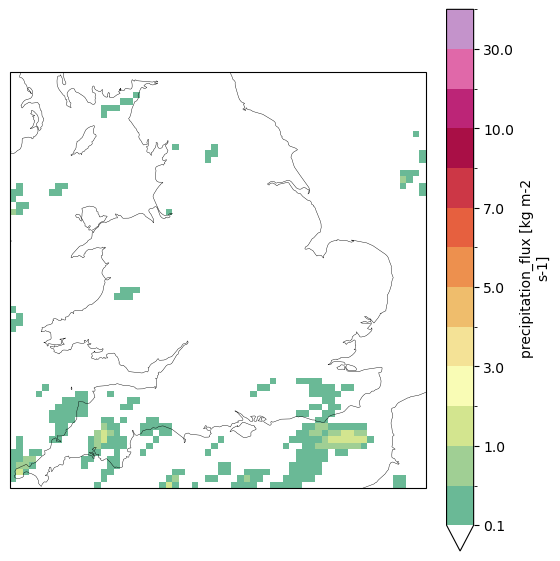

<xarray.Dataset> Size: 3GB
Dimensions:                     (grid_latitude: 64, bnds: 2, time: 17280,
                                 grid_longitude: 64, ensemble_member: 11)
Coordinates:
  * grid_latitude               (grid_latitude) float32 256B -2.49 ... 2.55
  * bnds                        (bnds) int64 16B 0 1
  * time                        (time) object 138kB 1981-03-01 00:30:00 ... 1...
  * grid_longitude              (grid_longitude) float32 256B 357.9 ... 363.0
  * ensemble_member             (ensemble_member) object 88B 'r001i1p01113' ....
Data variables:
    grid_latitude_bnds          (grid_latitude, bnds, time) float32 9MB -2.5 ...
    grid_longitude_bnds         (grid_longitude, bnds, time) float32 9MB 357....
    pr                          (ensemble_member, time, grid_latitude, grid_longitude) float32 3GB ...
    rotated_latitude_longitude  (time) float64 138kB -2.147e+09 ... -2.147e+09
    time_bnds                   (time, bnds) object 276kB 1981-03-01 00:00:00...
Attributes:
    Conventions:  CF-1.7
    domain:       engwales
    resolution:   2.2km-coarsened-4x
    frequency:    1hr

In [3]:
ds_dirpath = Path(
    os.getenv("DATA_PATH"), "datasets", "engwales_ccpm-4x_12em_1981-1990_1hr_pr", "val"
)
truth_ds = xr.load_dataset(ds_dirpath / "predictands.zarr", engine="zarr")#.isel(ensemble_member=0)
truth_ds["pr"] = truth_ds["pr"]*3600

fig = plt.figure(figsize=(5.5, 5.5), layout="constrained")
ax = fig.add_subplot(projection=cp_model_rotated_pole)
plot_map(truth_ds["pr"].isel(time=0).isel(ensemble_member=0), ax=ax, style="pr_hourly", add_colorbar=True)

plt.show()

truth_ds

720

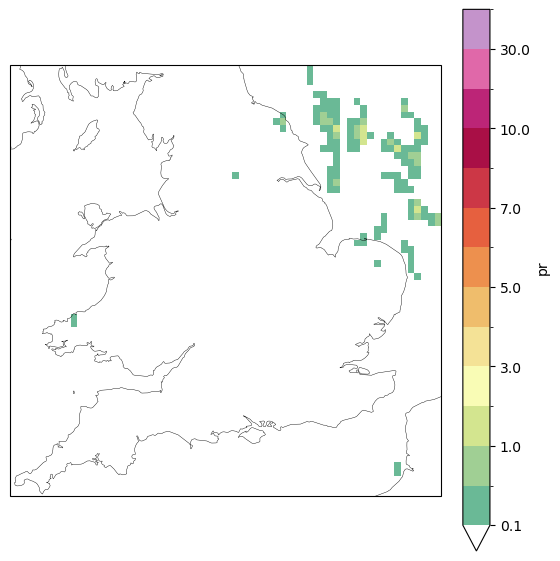

<xarray.Dataset> Size: 283MB
Dimensions:         (time: 720, frame: 24, grid_longitude: 64, grid_latitude: 64)
Coordinates:
  * time            (time) object 6kB 1981-03-01 00:00:00 ... 1990-05-30 00:0...
  * grid_longitude  (grid_longitude) float32 256B 357.9 358.0 ... 362.9 363.0
  * grid_latitude   (grid_latitude) float32 256B -2.49 -2.41 -2.33 ... 2.47 2.55
Dimensions without coordinates: frame
Data variables:
    pr              (time, frame, grid_latitude, grid_longitude) float32 283MB ...

In [10]:
pred_ds = xr.open_dataset(
    "/home/vf20964/furflex/workdirs/no-vae-invertable-sqrt-standardize-11em-pSTV-1981-1990-1hr-pr/CPMLatte-S-8-F24S1-cpm/samples/0200/val/predictions-GdVTUw3cmTV5Ay2mFHcPPi.zarr"
).isel(time=slice(0,len(truth_ds["time"])//24))
pred_ds["pr"] = pred_ds["pr"]*3600
pred_ds = pred_ds.assign_coords(grid_latitude=truth_ds["grid_latitude"].copy(), grid_longitude=truth_ds["grid_longitude"].copy())
# pred_ds["rotated_latitude_longitude"] = ([], 0, {**truth_ds["rotated_latitude_longitude"].attrs})
pred_ds["pr"] = (("time", "frame", "grid_longitude", "grid_latitude"), np.transpose(pred_ds["pr"].values, (0,1,3,2)))


pred_ds = pred_ds.transpose("time", "frame", "grid_latitude", "grid_longitude")

fig = plt.figure(figsize=(5.5, 5.5), layout="constrained")
ax = fig.add_subplot(projection=cp_model_rotated_pole)
plot_map(pred_ds["pr"].isel(time=0, frame=0), ax=ax, style="pr_hourly", add_colorbar=True)

plt.show()

pred_ds

In [15]:
def plot_truth_frame(da, frame, ax, _frames_per_day):
    truth_frame_da = da.isel(time=frame)
    pr_quad = plot_map(truth_frame_da, ax=ax, style="pr_hourly")
    ax.set_title(f"CPM {truth_frame_da["time"].item()}")
    
    return pr_quad

def plot_pred_frame(da, frame, ax, frames_per_day):
    idate = frame // frames_per_day
    iframe = frame % frames_per_day
    pred_frame_da = da.isel(time=idate, frame=iframe)
    pr_quad = plot_map(pred_frame_da, ax=ax, style="pr_hourly")
    pred_time = pred_frame_da["time"].item() + datetime.timedelta(hours=iframe, minutes=30)
    ax.set_title(f"Prediction {pred_time}")
    
    return pr_quad

def update(frame):
    updated_pr_quads = []

    pr_quad = plot_pred_frame(plot_pred_ds["pr"], frame, axd[f"pred"], frames_per_day)
    updated_pr_quads.append(pr_quad)

    pr_quad = plot_truth_frame(plot_truth_ds["pr"], frame, axd[f"truth"], frames_per_day)
    updated_pr_quads.append(pr_quad)
    
    return updated_pr_quads


start_day = 10
ndays = 2
frames_per_day = 24
interval=500

plot_pred_ds = pred_ds.isel(time=slice(start_day, start_day+ndays))
plot_truth_ds = truth_ds.isel(time=slice(start_day*frames_per_day, start_day*24+ndays*frames_per_day)).isel(ensemble_member=0)

subplot_kw = dict(projection=cp_model_rotated_pole)
fig = plt.figure(figsize=(5.5, 5.5), layout="constrained")
axd = fig.subplot_mosaic([["pred", "truth"]], subplot_kw=subplot_kw)

pr_quads = []

pr_quad = plot_pred_frame(plot_pred_ds["pr"], 0, axd["pred"], frames_per_day)
pr_quads.append(pr_quad)

pr_quad = plot_truth_frame(plot_truth_ds["pr"], 0, axd["truth"], frames_per_day)
pr_quads.append(pr_quad)

cb = fig.colorbar(
    pr_quads[0],
    ax=axd.values(),
    location="bottom",
    orientation="horizontal",
    shrink=0.8,
    extend="both",
)
cb.ax.tick_params(axis="both", which="major", labelsize="small")
cb.set_label("Precip [mm/hr]", fontsize="small")

anim = animation.FuncAnimation(fig, update, frames=ndays*frames_per_day, blit=False, interval=interval)

filepath = None
filepath = "hourly_precip.gif"
if filepath is not None:
    anim.save(filepath, 
              writer='pillow', 
              fps=int(1000/interval))
    print(f"Animation saved as '{filepath}'")

plt.close(fig)  # prevent double display in notebook
# Display as HTML5 video (works in JupyterLab)
display_html(HTML(anim.to_html5_video()))

Animation saved as 'hourly_precip.gif'


Your browser does not support the video tag.

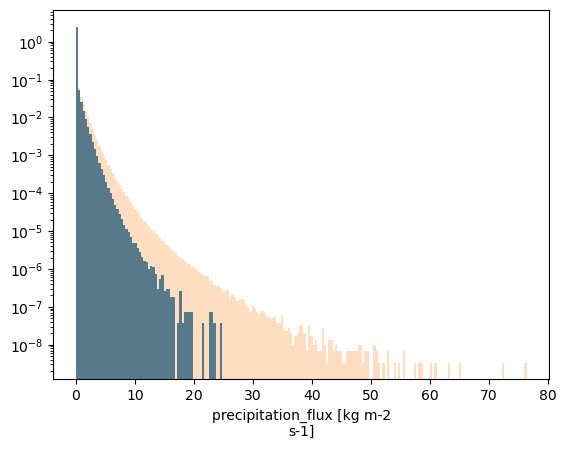

In [15]:
ax = plt.subplot()
bins=np.histogram_bin_edges([], bins=200, range=(0, max(pred_ds["pr"].max().item(), truth_ds["pr"].max().item())))
pred_ds["pr"].plot(ax=ax, bins=bins, density=True)
truth_ds["pr"].plot(ax=ax, bins=bins, alpha=0.25, density=True)
ax.set_yscale("log")